# Thesis: Managing Ambiguity in Cloud Computing Requirements Classification: LLM-Based Disambiguation and BERT-Based Evaluation

## Introduction

Cloud computing requirements are often written in natural language, which introduces ambiguity and can affect automated requirement analysis. Previous work (AI-CRAS) used a fine-tuned BERT model to classify sentences from requirement documents as requirements or non-requirements. 

In this study, we extend the same dataset by labeling sentences according to different types of ambiguity (lexical, syntactic, semantic, language-error, and pragmatic). We then evaluate whether ambiguity affects BERT classification performance and whether Large Language Models (LLMs) can improve results by rewriting ambiguous requirements before classification.

## Data
### Data Collection Procedure

The experiments in this notebook use the same dataset introduced in the AI-CRAS framework for cloud requirement classification. The dataset was built from publicly available Request for Proposal (RFP) documents related to cloud computing and manually labeled according to predefined cloud service categories. Understanding how the dataset was collected and annotated is important for interpreting the results of the experiments.

### Data Enrichment

To support the analysis of ambiguity in cloud computing requirements, the original dataset was enriched with additional manually annotated columns. Specifically, two types of annotations were introduced.

- First, a binary column `is_ambiguous` was added to indicate whether a sentence contains any form of ambiguity. 
- Second, a set of more specific columns was introduced to capture the presence of particular types of ambiguity. Each column follows the format `is_{type_of_ambiguity}_ambiguous`, indicating whether the sentence exhibits a specific ambiguity category (e.g., lexical, syntactic, semantic, language error, or pragmatic).

These annotations were manually added in order to enable more detailed experiments on the impact of ambiguity in requirement classification and to support subsequent disambiguation procedures using Large Language Models.

### Data Exploration

Now let's visualize the dataframe

In [73]:
# Importing libraries
import numpy as np
import pandas as pd
from sklearn import metrics
import transformers
import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertModel, BertConfig
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from modules.bert_pipeline import (
    BertExperimentConfig,
    BERTClass,
    CustomDataset,
    DEFAULT_TARGET_LIST,
    build_dataloaders,
    build_model_and_optimizer,
    compute_distribution_classes,
    get_tokenizer,
    loss_fn,
    prepare_baseline_dataframe,
    test_model,
    train_model,
    validate_multilabel
)
from modules.bert_evaluation import (
    build_validation_results_dataframes,
    evaluate_model,
    export_validation_results,
)
from modules.bert_experiments import (
    run_experiment,
    run_experiment_suite,
)


In [74]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

print("Device:", device)

Using MPS (Apple GPU)
Device: mps


In [75]:
# Store the dataset in a Dataframe
df = pd.read_csv("data/dataframe.csv")
SEED = 42 # for reproducibility


### Data Exploration


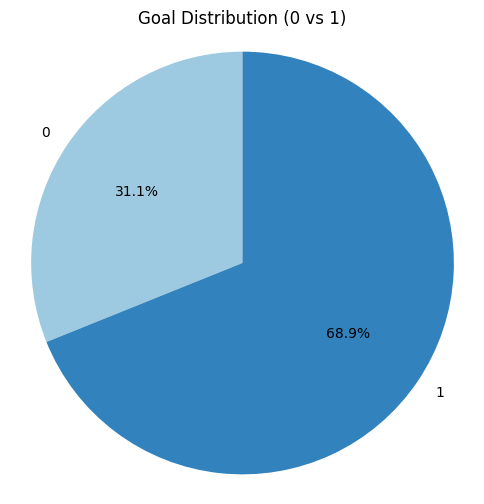

In [76]:
# Pie chart: distribution of goal (0 vs 1)
goal_counts = pd.to_numeric(df['goal'], errors='coerce').fillna(0).astype(int).value_counts().reindex([0, 1], fill_value=0)

plt.figure(figsize=(6, 6))
plt.pie(goal_counts.values, labels=['0', '1'], autopct='%1.1f%%', startangle=90, colors=['#9ecae1', '#3182bd'])
plt.title('Goal Distribution (0 vs 1)')
plt.axis('equal')
plt.show()


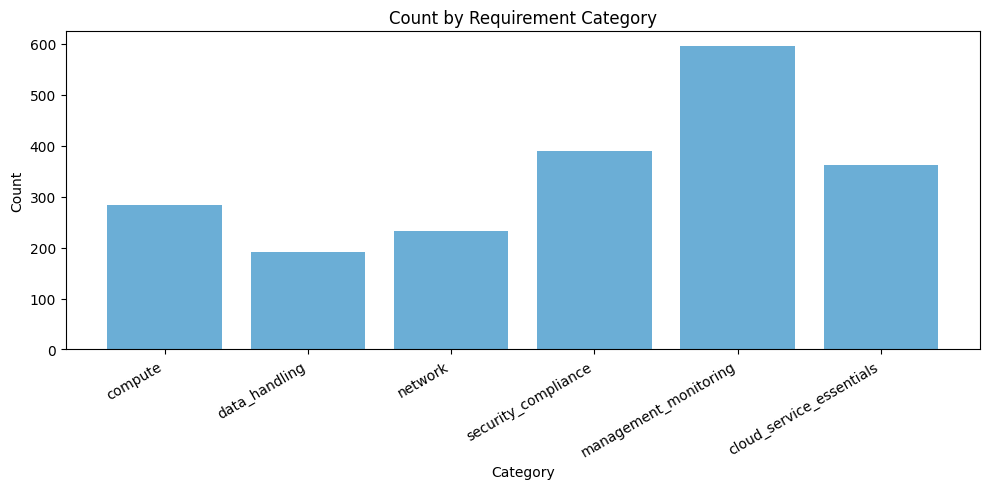

In [77]:
# Histogram/bar chart: count of positive labels in each requirement category
label_cols = ['compute', 'data_handling', 'network', 'security_compliance', 'management_monitoring', 'cloud_service_essentials']
label_counts = df[label_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum().astype(int)

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color='#6baed6')
plt.title('Count by Requirement Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


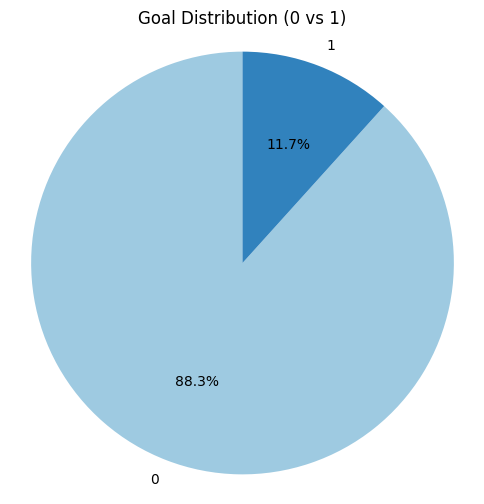

In [78]:

# Pie chart: distribution of ambiguity (0 vs 1)
goal_counts = pd.to_numeric(df['ambuiguity'], errors='coerce').fillna(0).astype(int).value_counts().reindex([0, 1], fill_value=0)

plt.figure(figsize=(6, 6))
plt.pie(goal_counts.values, labels=['0', '1'], autopct='%1.1f%%', startangle=90, colors=['#9ecae1', '#3182bd'])
plt.title('Goal Distribution (0 vs 1)')
plt.axis('equal')
plt.show()

/var/folders/z1/_f1dgn9d3vg65st2m_lw8_3c0000gn/T/ipykernel_3665/2453165783.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_cols, rotation=30, ha='right')


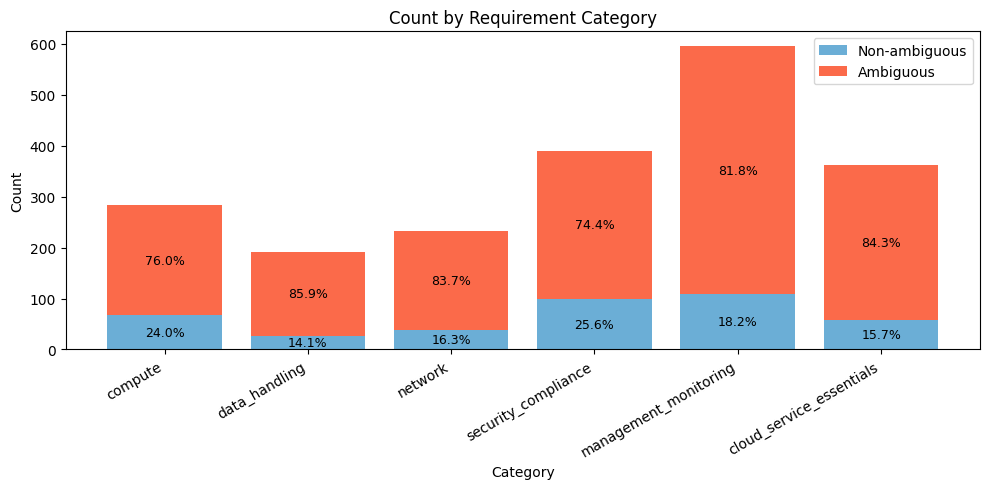

In [79]:

# Convert labels to numeric
labels = df[label_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Replace with your actual ambiguity column
ambiguous_mask = df['ambuiguity'].astype(bool)

# Counts per category
ambiguous_counts = labels[ambiguous_mask].sum()
non_ambiguous_counts = labels[~ambiguous_mask].sum()
totals = ambiguous_counts + non_ambiguous_counts

# Percentages within each category
ambiguous_pct = (ambiguous_counts / totals * 100).fillna(0)
non_ambiguous_pct = (non_ambiguous_counts / totals * 100).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

bars_non = ax.bar(
    label_cols, non_ambiguous_counts,
    color='#6baed6', label='Non-ambiguous'
)

bars_amb = ax.bar(
    label_cols, ambiguous_counts,
    bottom=non_ambiguous_counts,
    color='#fb6a4a', label='Ambiguous'
)

# Add percentage labels inside each segment
for i, cat in enumerate(label_cols):
    non_count = non_ambiguous_counts.iloc[i]
    amb_count = ambiguous_counts.iloc[i]
    non_pct = non_ambiguous_pct.iloc[i]
    amb_pct = ambiguous_pct.iloc[i]

    if non_count > 0:
        ax.text(
            i, non_count / 2,
            f'{non_pct:.1f}%',
            ha='center', va='center', color='black', fontsize=9
        )

    if amb_count > 0:
        ax.text(
            i, non_count + amb_count / 2,
            f'{amb_pct:.1f}%',
            ha='center', va='center', color='black', fontsize=9
        )

ax.set_title('Count by Requirement Category')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_xticklabels(label_cols, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Methodology

This study uses a BERT-based multi-label classifier as the benchmark model for cloud requirement classification. The architecture and training setup follow the baseline adopted in Casalicchio et al. (2022): a bert-base-uncased encoder with a dropout layer and a linear classification head producing one output for each requirement category. The evaluation setup implemented in bert_evaluation.py is kept aligned with this benchmark so that all later experiments remain directly comparable to the original BERT results.

The starting point is the full labeled dataset, which includes both ambiguous and non-ambiguous sentences. After standard preprocessing and duplicate removal, the benchmark classifier is trained and evaluated using the parameters defined in bert_pipeline.py. These parameters are treated as the baseline configuration. The first experimental step is to investigate whether ambiguity negatively affects classification performance by removing ambiguous sentences from the training and evaluation data and rerunning the same BERT pipeline. This can be interpreted as a form of data filtering rather than strict machine unlearning, since the ambiguous instances are excluded before training rather than removed from a model after training. Once the ambiguity-filtered dataset is defined, we test whether the same training configuration remains optimal or whether the pipeline parameters in bert_pipeline.py can be adjusted to improve results on the reduced dataset.

After this global ambiguity-removal experiment, the analysis is refined by removing only sentences associated with specific ambiguity categories, such as lexical, syntactic, semantic, language-error, or pragmatic ambiguity. For each category-specific subset, the same benchmark BERT pipeline is rerun and evaluated with the shared metrics module. This allows us to compare how different ambiguity types affect classification quality and whether some categories are more harmful than others.

In the final stage, we move from removing ambiguity to resolving it. Ambiguous sentences are rewritten through Large Language Models in order to produce disambiguated variants while preserving their original meaning as much as possible. These rewritten datasets are then used as input to the same BERT benchmark classifier, and performance is compared against both the original dataset and the ambiguity-filtered variants. A final set of experiments applies LLM-based disambiguation only to sentences belonging to specific ambiguity categories, allowing us to test whether targeted disambiguation yields better results than global rewriting.

Overall, the methodology is structured as a sequence of controlled comparisons:

- benchmark_classifier: baseline BERT on the original dataset,
- BERT after removing all ambiguous sentences,
- BERT after removing ambiguity by specific category,
- BERT after LLM-based disambiguation of all ambiguous sentences,
- BERT after LLM-based disambiguation for selected ambiguity categories.

This design makes it possible to isolate the effect of ambiguity, compare removal versus rewriting strategies, and measure whether targeted ambiguity handling improves requirement classification performance.

## Feature Engineering
Here I should describe how I will prepare the dataset for the analysis

In [64]:
# Check for any missing values in the dataset
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
source                         0
description                    0
goal                           0
compute                        0
data_handling                  0
                            ... 
management_monitoring          0
cloud_service_essentials       0
ambiguity_type              1482
ambuiguity                  1482
comments                    1964
Length: 12, dtype: int64


In [66]:
target_list = DEFAULT_TARGET_LIST.copy()
display_target_list = [label.replace('_', ' ') for label in target_list]

# Convert benchmark labels to integers before any split or export
df[target_list] = df[target_list].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2164 entries, 0 to 2163
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   source                    2164 non-null   object 
 1   description               2164 non-null   object 
 2   goal                      2164 non-null   int64  
 3   compute                   2164 non-null   int64  
 4   data_handling             2164 non-null   int64  
 5   network                   2164 non-null   int64  
 6   security_compliance       2164 non-null   int64  
 7   management_monitoring     2164 non-null   int64  
 8   cloud_service_essentials  2164 non-null   int64  
 9   ambiguity_type            682 non-null    float64
 10  ambuiguity                682 non-null    float64
 11  comments                  200 non-null    object 
dtypes: float64(2), int64(7), object(3)
memory usage: 203.0+ KB


In [67]:
df["description"] = df["description"].str.strip()
df["description"] = df["description"].str.rstrip('.')

In [68]:
# Convert 'description' to lowercase for a case-insensitive duplicate check and store in a temporary column
df['temp_description_lower'] = df['description'].str.lower()

# Check for duplicates (put on variable to print)
duplicates_case_insensitive = df['temp_description_lower'].duplicated().sum()

# Drop duplicates based on the temporary lowercase column, keeping the first occurrence
df = df.drop_duplicates(subset=["temp_description_lower"], keep='first')

# Drop the temporary column
df = df.drop(columns=['temp_description_lower']).reset_index(drop=True)

print(f"Number of case-insensitive duplicates: {duplicates_case_insensitive}")


Number of case-insensitive duplicates: 0


In [69]:
baseline_train_df = prepare_baseline_dataframe(df, target_list=target_list)

In [70]:
print(len(baseline_train_df))

2164


In [71]:
pd.set_option('display.max_rows', 10)

baseline_train_df

,description,compute,data_handling,network,security_compliance,management_monitoring,cloud_service_essentials
0,The Bidder will be responsible for provisionin...,1,1,1,0,0,0
1,The proposed landscape for the deployment of N...,0,0,0,0,0,0
2,The above environments are to be deployed on t...,0,0,1,0,0,0
3,The environment of Virtual Private Cloud/Gover...,0,0,0,1,0,0
4,Each of the environments mentioned above shoul...,0,0,1,0,0,0
...,...,...,...,...,...,...,...
2159,Any additional costing as per vendor specifica...,0,0,0,0,0,0
2160,The hosted virtual servers should only be bill...,0,0,0,0,1,0
2161,Any virtual servers that are switched off will...,0,0,0,0,1,0
2162,Costing must be on a resource use basis,0,0,0,0,0,0


### Experiment Runner

The notebook now uses the high-level runner in `modules.bert_experiments.py` for the baseline experiment. This keeps the notebook concise and makes it easier to repeat the same workflow over multiple dataframe subsets later.


In [17]:
# Shared BERT pipeline configuration used throughout the notebook
experiment_config = BertExperimentConfig(
    max_len=300,
    train_batch_size=16,
    valid_batch_size=16,
    epochs=5,
    learning_rate=3e-05,
    seed=SEED,
)

MAX_LEN = experiment_config.max_len
TRAIN_BATCH_SIZE = experiment_config.train_batch_size
VALID_BATCH_SIZE = experiment_config.valid_batch_size
EPOCHS = experiment_config.epochs
LEARNING_RATE = experiment_config.learning_rate

# Optional exports: keep disabled unless you explicitly want artifacts on disk
EXPORT_INTERMEDIATE_DATASETS = False
EXPORT_VALIDATION_RESULTS = True

tokenizer = get_tokenizer(experiment_config)


## Analysis
### Model Definition

Model construction, training, evaluation, and optional export are orchestrated by the experiment runner. The notebook defines a dictionary of dataframe experiments, runs them through `run_experiment_suite(...)`, and then reuses the `baseline` outputs for the detailed analysis cells below.


### benchmark_classifier

This baseline run uses the full cleaned benchmark dataframe and stores the outputs in a single experiment result object that can later be reproduced in a loop for subset comparisons.


In [ ]:
experiment_dfs = {
    "baseline": baseline_train_df,
    # "no_ambiguity": no_ambiguity_df,
    # "no_lexical_ambiguity": no_lexical_ambiguity_df,
}

all_runs, summary_df = run_experiment_suite(
    experiments=experiment_dfs,
    device=device,
    config=experiment_config,
    target_list=target_list,
    artifacts_dir="artifacts",
    export_validation_results=EXPORT_VALIDATION_RESULTS,
)

baseline_run = all_runs[0]

best_model_path = baseline_run["model_path"]
trained_model = baseline_run["model"]
loaded_model = baseline_run["model"]
tokenizer = baseline_run["tokenizer"]
train_df_1 = baseline_run["train_df"]
val_df = baseline_run["val_df"]
train_data_loader = baseline_run["train_loader"]
val_data_loader = baseline_run["val_loader"]
train_distribution = baseline_run["train_distribution"]
val_distribution = baseline_run["val_distribution"]
training_losses = baseline_run["training_losses"]
validation_losses = baseline_run["validation_losses"]
epochs_list = baseline_run["epochs_list"]
evaluation = baseline_run["evaluation"]
results_df = baseline_run["results_df"]
confusion_matrix_df = baseline_run["confusion_matrix_df"]
export_summary = baseline_run["export_summary"]

THRESHOLD = evaluation["threshold"]
targets = evaluation["targets"]
probs = evaluation["probabilities"]
outputs = evaluation["outputs"]
targets_array = evaluation["targets_array"]
outputs_array = evaluation["outputs_array"]
probs_array = evaluation["probabilities_array"]
binary_metrics = evaluation["binary_metrics"]

print(summary_df)
print(f"\nBest model path: {best_model_path}")
if baseline_run["results_path"]:
    print(f"Validation results path: {baseline_run['results_path']}")
print(f"Precision: {export_summary['precision']:.4f}")
print(f"Recall: {export_summary['recall']:.4f}")


############# Epoch 1: Training Start #############


KeyboardInterrupt: 

In [ ]:
# Optionally log experiment metadata to a local text file
log_file_path = './experiments.txt'

experiment_data = {
    "MODEL": "bert-base-uncased baseline",
    "MAX_LEN": MAX_LEN,
    "BATCH_SIZE": TRAIN_BATCH_SIZE,
    "LEARNING_RATE": LEARNING_RATE,
    "SEED": SEED,
    "Train Distribution": str(train_distribution),
    "Validation Distribution": str(val_distribution),
    "Last Training Loss": training_losses[-1] if training_losses else "Not Available",
    "Last Validation Loss": validation_losses[-1] if validation_losses else "Not Available",
    "Last Epoch": epochs_list[-1] if epochs_list else "Not Available",
}

with open(log_file_path, "a") as file:
    file.write("Experiment Details:\n")
    for key, value in experiment_data.items():
        file.write(f"{key}: {value}\n")
    file.write("\n")

print("Experiment details logged.")


Experiment details logged.


In [ ]:
# Plot training and validation loss
plt.plot(epochs_list, training_losses, label='train')
plt.plot(epochs_list, validation_losses, label='valid')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


## Load a Saved Checkpoint

This section is optional if you want to reload a saved model manually. The training cell above already evaluates the freshly trained best model.


In [ ]:
def load_model_state(model, saved_model_path, device):
    """Load a saved model state into the provided architecture."""
    model = model.to(device)
    model.load_state_dict(torch.load(saved_model_path, map_location=device))
    return model


In [ ]:
# Load either the freshly trained best model or another saved state
saved_model_path = './best_model.pt'

loaded_model = BERTClass(num_labels=len(target_list))
loaded_model = load_model_state(loaded_model, saved_model_path, device)
loaded_model.eval()


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

## Validation Metrics


In [ ]:
# Evaluation was already computed after training; rerun this cell only if you reloaded another checkpoint above.


### Binary Requirement Detection

Treat a sentence as a requirement if the model assigns at least one positive category above the threshold.


In [ ]:
print("Classification Report:")
print(binary_metrics["classification_report"])


Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.71      0.79       103
        True       0.88      0.96      0.92       222

    accuracy                           0.88       325
   macro avg       0.89      0.84      0.86       325
weighted avg       0.88      0.88      0.88       325



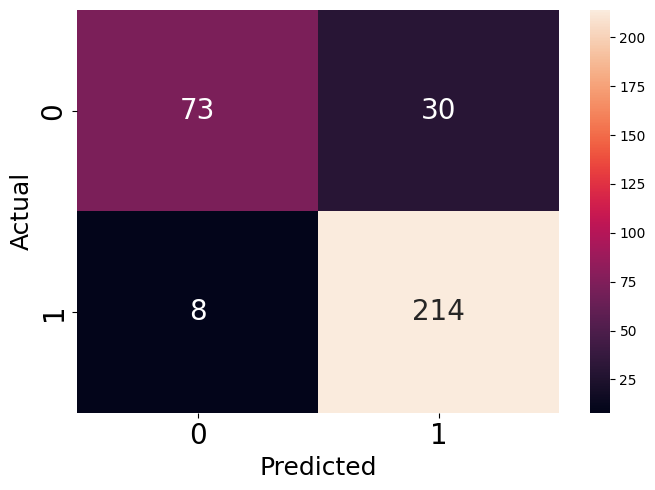

In [ ]:
conf_matrix = binary_metrics["confusion_matrix"]

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', annot_kws={"size": 20})
plt.ylabel('Actual', fontsize=18)
plt.xlabel('Predicted', fontsize=18)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()


### Multi-Label Category Evaluation

These metrics evaluate how well the classifier predicts the six requirement categories themselves.


In [ ]:
print("Accuracy Score:", evaluation["exact_match_accuracy"])


Accuracy Score: 0.6307692307692307


In [ ]:
print(evaluation["classification_report"])


                          precision    recall  f1-score   support

                 compute       0.60      0.86      0.70        50
           data handling       0.64      0.90      0.75        30
                 network       0.63      0.84      0.72        31
   security & compliance       0.79      0.89      0.84        63
 management & monitoring       0.86      0.79      0.82        90
cloud service essentials       0.65      0.87      0.74        52

               micro avg       0.71      0.85      0.77       316
               macro avg       0.70      0.86      0.76       316
            weighted avg       0.73      0.85      0.78       316
             samples avg       0.55      0.59      0.55       316



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
print("Hamming Loss:", evaluation["hamming_loss"])
print("Jaccard Similarity Score:", evaluation["jaccard_score"])


Hamming Loss: 0.08102564102564103
Jaccard Similarity Score: 0.619275600208644


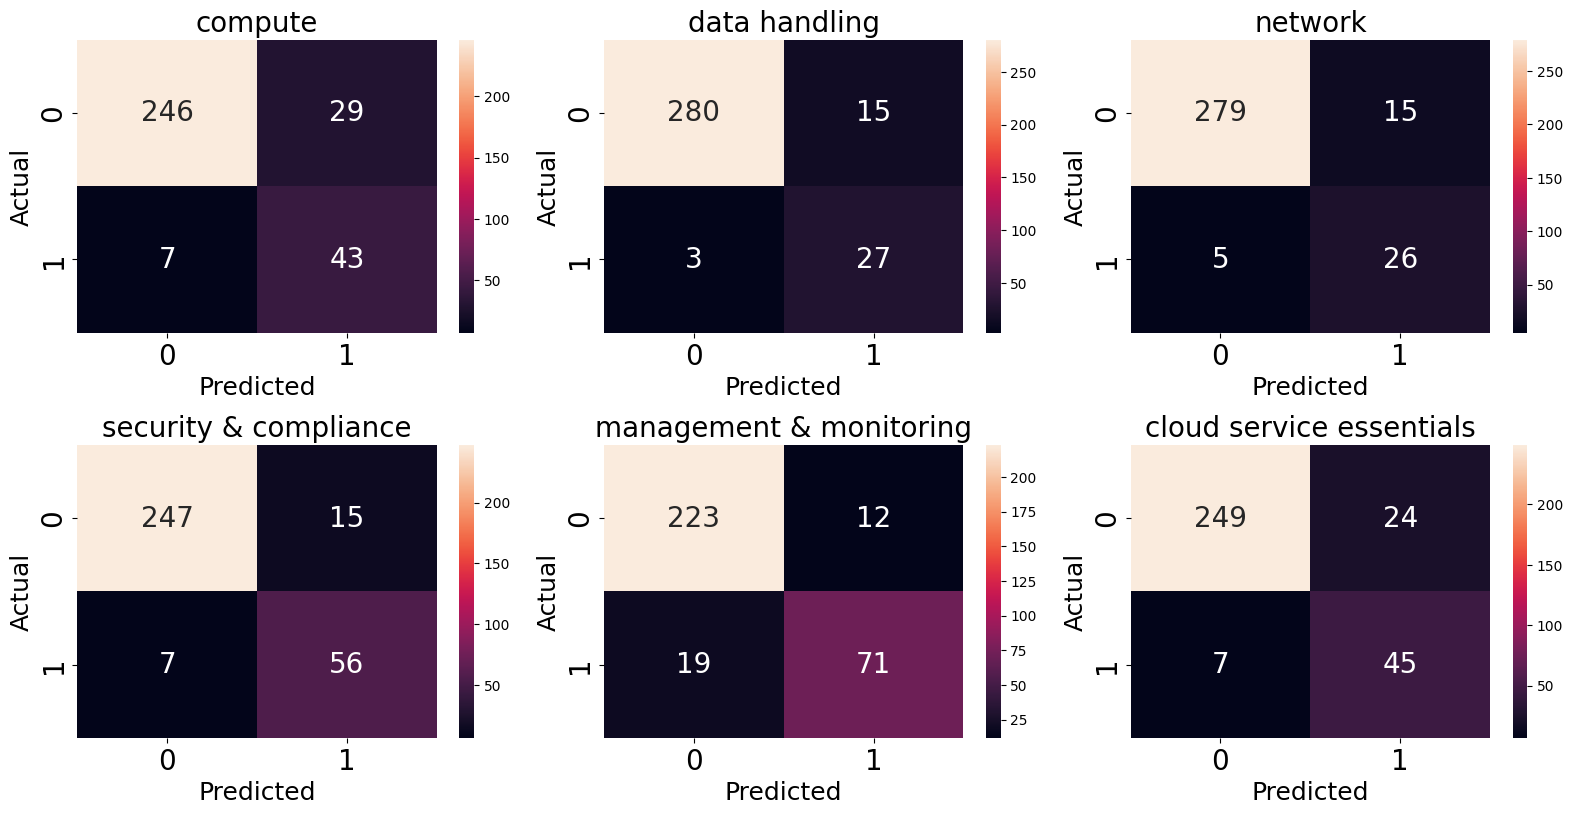

In [ ]:
plt.figure(figsize=(16, 12))
for i, label in enumerate(display_target_list):
    cm = evaluation["per_label_confusion_matrices"][target_list[i]]
    plt.subplot(3, 3, i + 4)
    sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 20})
    plt.title(label, fontsize=20)
    plt.ylabel('Actual', fontsize=18)
    plt.xlabel('Predicted', fontsize=18)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

plt.tight_layout()
plt.show()


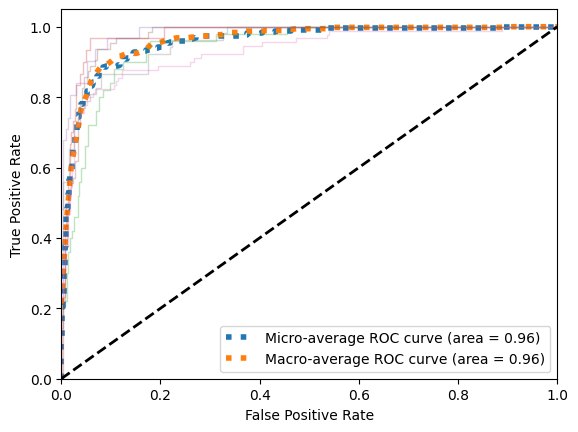

In [ ]:
roc_data = evaluation["roc_data"]
fpr = roc_data["fpr"]
tpr = roc_data["tpr"]
roc_auc = roc_data["roc_auc"]

plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label='Micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]),
    linestyle=':',
    linewidth=4,
)
plt.plot(
    fpr["macro"],
    tpr["macro"],
    label='Macro-average ROC curve (area = {0:0.2f})'.format(roc_auc["macro"]),
    linestyle=':',
    linewidth=4,
)

for label in target_list:
    plt.plot(fpr[label], tpr[label], lw=1, alpha=0.3, label=label.replace('_', ' '))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro and Micro ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [ ]:
for label in target_list:
    display_label = label.replace('_', ' ')
    accuracy = evaluation["per_label_accuracies"][label]
    print(f"Accuracy for {display_label}: {accuracy * 100:.2f}%")


Accuracy for label 0: 88.92%
Accuracy for label 1: 94.46%
Accuracy for label 2: 93.85%
Accuracy for label 3: 93.23%
Accuracy for label 4: 90.46%
Accuracy for label 5: 90.46%


## Inference Example


### Test the Classifier on a Single Sentence


In [ ]:
test_sentence = "Solution must provide replication at appropriate level including virtual machine and storage level between primary and DR site"

predicted_labels, predictions = test_model(
    test_sentence,
    loaded_model,
    tokenizer,
    MAX_LEN,
    0.20,
    device,
    target_list,
)

label_intensity = {label.replace('_', ' '): round(prob, 3) for label, prob in zip(target_list, predictions[0])}
predicted_display_labels = [label.replace('_', ' ') for label in predicted_labels]

print("Sentence:", test_sentence)
print("Predicted Labels and Intensity:", {label: label_intensity[label] for label in predicted_display_labels})


Sentence:  Solution must provide replication at appropriate level including virtual machine and storage level between primary and DR site
Predicted Labels and Intensity: {'data handling': 0.77, 'cloud service essentials': 0.725}


## Export Validation Predictions

Validation predictions are already prepared during training. The cells below simply inspect the saved `results_df`, `confusion_matrix_df`, and `export_summary` objects.


In [ ]:
print(f"Saved validation rows: {len(results_df)}")
print(f"Precision: {export_summary['precision']:.4f}")
print(f"Recall: {export_summary['recall']:.4f}")


Precision: 0.8770
Recall: 0.9640


## Future Subset Experiments

This notebook is now ready to rerun the same baseline pipeline on filtered subsets such as:
- no ambiguity
- no lexical ambiguity
- no syntactic ambiguity
- no semantic ambiguity
- no language-error ambiguity
- no pragmatic ambiguity

The shared helpers in `bert_pipeline.py` are intended to make those experiments repeatable without duplicating the training code.


## Future LLM-Disambiguated Experiments

A parallel set of experiments can be run on LLM-rewritten versions of the same ambiguity subsets once those rewritten datasets are available.


## Analysis


## Conclusion
